<a href="https://colab.research.google.com/github/s-gopi7/EMPLOYEE-EXIT-SURVEY-ANALYSIS/blob/main/EMPLOYEE_EXIT_SURVEY_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
 # Settings

pd.options.display.max_columns = 80
pd.options.display.max_rows = 700
%matplotlib inline
 # Load data
dete = pd.read_csv('/content/dete-employee-exit-survey.csv', na_values='Not Stated')
tafe = pd.read_csv('/content/tafe_survey (1).csv',encoding = 'Windows-1252')
# Drop unnecessary columns
dete = dete.drop(columns=dete.columns[28:49])
tafe = tafe.drop(columns=tafe.columns[18:66])
print("data set",dete)
print("tafe data",tafe)



data set       ID                        SeparationType Cease Date  DETE Start Date  \
0      1                 Ill Health Retirement    08/2012           1984.0   
1      2      Voluntary Early Retirement (VER)    08/2012              NaN   
2      3      Voluntary Early Retirement (VER)    05/2012           2011.0   
3      4             Resignation-Other reasons    05/2012           2005.0   
4      5                        Age Retirement    05/2012           1970.0   
..   ...                                   ...        ...              ...   
817  819                        Age Retirement    02/2014           1977.0   
818  820                        Age Retirement    01/2014           1980.0   
819  821  Resignation-Move overseas/interstate    01/2014           2009.0   
820  822                 Ill Health Retirement    12/2013           2001.0   
821  823  Resignation-Move overseas/interstate    12/2013              NaN   

     Role Start Date                                  

In [2]:
print(dete.shape)
print(dete.info())
display(dete.head())

(822, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   822 non-null    int64  
 1   SeparationType                       822 non-null    object 
 2   Cease Date                           788 non-null    object 
 3   DETE Start Date                      749 non-null    float64
 4   Role Start Date                      724 non-null    float64
 5   Position                             817 non-null    object 
 6   Classification                       455 non-null    object 
 7   Region                               717 non-null    object 
 8   Business Unit                        126 non-null    object 
 9   Employment Status                    817 non-null    object 
 10  Career move to public sector         822 non-null    bool   
 11  Career move to private

,ID,SeparationType,Cease Date,DETE Start Date,Role Start Date,Position,Classification,Region,Business Unit,Employment Status,Career move to public sector,Career move to private sector,Interpersonal conflicts,Job dissatisfaction,Dissatisfaction with the department,Physical work environment,Lack of recognition,Lack of job security,Work location,Employment conditions,Maternity/family,Relocation,Study/Travel,Ill Health,Traumatic incident,Work life balance,Workload,None of the above,Gender,Age,Aboriginal,Torres Strait,South Sea,Disability,NESB
0,1,Ill Health Retirement,08/2012,1984.0,2004.0,Public Servant,A01-A04,Central Office,Corporate Strategy and Peformance,Permanent Full-time,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,Male,56-60,NaN,NaN,NaN,NaN,Yes
1,2,Voluntary Early Retirement (VER),08/2012,NaN,NaN,Public Servant,AO5-AO7,Central Office,Corporate Strategy and Peformance,Permanent Full-time,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Male,56-60,NaN,NaN,NaN,NaN,NaN
2,3,Voluntary Early Retirement (VER),05/2012,2011.0,2011.0,Schools Officer,NaN,Central Office,Education Queensland,Permanent Full-time,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,Male,61 or older,NaN,NaN,NaN,NaN,NaN
3,4,Resignation-Other reasons,05/2012,2005.0,2006.0,Teacher,Primary,Central Queensland,NaN,Permanent Full-time,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Female,36-40,NaN,NaN,NaN,NaN,NaN
4,5,Age Retirement,05/2012,1970.0,1989.0,Head of Curriculum/Head of Special Education,NaN,South East,NaN,Permanent Full-time,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,Female,61 or older,NaN,NaN,NaN,NaN,NaN


In [3]:
print(tafe.shape)
print(tafe.info())
display(tafe.head())


(702, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 24 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   Record ID                                                                  702 non-null    int64  
 1   Institute                                                                  702 non-null    object 
 2   WorkArea                                                                   702 non-null    object 
 3   CESSATION YEAR                                                             695 non-null    float64
 4   Reason for ceasing employment                                              701 non-null    object 
 5   Contributing Factors. Career Move - Public Sector                          437 non-null    object 
 6   Contributing Factors. Career Move - Private Sect

,Record ID,Institute,WorkArea,CESSATION YEAR,Reason for ceasing employment,Contributing Factors. Career Move - Public Sector,Contributing Factors. Career Move - Private Sector,Contributing Factors. Career Move - Self-employment,Contributing Factors. Ill Health,Contributing Factors. Maternity/Family,Contributing Factors. Dissatisfaction,Contributing Factors. Job Dissatisfaction,Contributing Factors. Interpersonal Conflict,Contributing Factors. Study,Contributing Factors. Travel,Contributing Factors. Other,Contributing Factors. NONE,Main Factor. Which of these was the main factor for leaving?,Gender. What is your Gender?,CurrentAge. Current Age,Employment Type. Employment Type,Classification. Classification,LengthofServiceOverall. Overall Length of Service at Institute (in years),LengthofServiceCurrent. Length of Service at current workplace (in years)
0,634133009996094000,Southern Queensland Institute of TAFE,Non-Delivery (corporate),2010.0,Contract Expired,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,26 – 30,Temporary Full-time,Administration (AO),1-2,1-2
1,634133654064531000,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Retirement,-,-,-,-,-,-,-,-,-,Travel,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,634138845606563000,Mount Isa Institute of TAFE,Delivery (teaching),2010.0,Retirement,-,-,-,-,-,-,-,-,-,-,-,NONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,634139903350000000,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Resignation,-,-,-,-,-,-,-,-,-,Travel,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,634146578511788000,Southern Queensland Institute of TAFE,Delivery (teaching),2010.0,Resignation,-,Career Move - Private Sector,-,-,-,-,-,-,-,-,-,-,NaN,Male,41 – 45,Permanent Full-time,Teacher (including LVT),3-4,3-4


In [4]:
dete.columns = dete.columns.str.lower().str.strip().str.replace(' ', '_')
tafe.rename(columns={
 'Record ID': 'id',
 'CESSATION YEAR': 'cease_date',
 'Reason for ceasing employment': 'separationtype',
 'Gender. What is your Gender?': 'gender',
 'CurrentAge. Current Age': 'age',
 'Employment Type. Employment Type': 'employment_status',
 'Classification. Classification': 'position',
 'LengthofServiceOverall. Overall Length of Service at Ianstitute (in years)': 'institute_service',
 'LengthofServiceCurrent. Length of Service at current workplace (in years)': 'role_service'
 }, inplace=True)
print("DETE Columns:", dete.columns.tolist())
print("\nTAFE Columns:", tafe.columns.tolist())


DETE Columns: ['id', 'separationtype', 'cease_date', 'dete_start_date', 'role_start_date', 'position', 'classification', 'region', 'business_unit', 'employment_status', 'career_move_to_public_sector', 'career_move_to_private_sector', 'interpersonal_conflicts', 'job_dissatisfaction', 'dissatisfaction_with_the_department', 'physical_work_environment', 'lack_of_recognition', 'lack_of_job_security', 'work_location', 'employment_conditions', 'maternity/family', 'relocation', 'study/travel', 'ill_health', 'traumatic_incident', 'work_life_balance', 'workload', 'none_of_the_above', 'gender', 'age', 'aboriginal', 'torres_strait', 'south_sea', 'disability', 'nesb']

TAFE Columns: ['id', 'Institute', 'WorkArea', 'cease_date', 'separationtype', 'Contributing Factors. Career Move - Public Sector ', 'Contributing Factors. Career Move - Private Sector ', 'Contributing Factors. Career Move - Self-employment', 'Contributing Factors. Ill Health', 'Contributing Factors. Maternity/Family', 'Contributing F

In [5]:
# Filter for resignation separation types in both datasets
dete_res = dete[dete['separationtype'].str.contains('resignation', case=False, na=False)].copy()
tafe_res = tafe[tafe['separationtype'].str.contains('resignation', case=False, na=False)].copy()

# Fix dates and compute service years for DETE dataset
dete_res['cease_date'] = dete_res['cease_date'].str.extract(r'(\d{4})').astype(float)
dete_res['institute_service'] = dete_res['cease_date'] - dete_res['dete_start_date']

# Print sample results
print("DETE Resignations:")
print(dete_res[['separationtype', 'cease_date', 'dete_start_date', 'institute_service']].head())

print("\nTAFE Resignations:")
# First check what columns are actually available in tafe_res
print("Available columns in TAFE:", tafe_res.columns.tolist())

# Then print the available columns you're interested in
# For example, if TAFE has different column names:
if 'Contributing Factors. Career Move - Public Sector ' in tafe_res.columns:
    print(tafe_res[['separationtype', 'Contributing Factors. Career Move - Public Sector ']].head())
else:
    print(tafe_res[['separationtype']].head())

DETE Resignations:
                          separationtype  cease_date  dete_start_date  \
3              Resignation-Other reasons      2012.0           2005.0   
5              Resignation-Other reasons      2012.0           1994.0   
8              Resignation-Other reasons      2012.0           2009.0   
9             Resignation-Other employer      2012.0           1997.0   
11  Resignation-Move overseas/interstate      2012.0           2009.0   

    institute_service  
3                 7.0  
5                18.0  
8                 3.0  
9                15.0  
11                3.0  

TAFE Resignations:
Available columns in TAFE: ['id', 'Institute', 'WorkArea', 'cease_date', 'separationtype', 'Contributing Factors. Career Move - Public Sector ', 'Contributing Factors. Career Move - Private Sector ', 'Contributing Factors. Career Move - Self-employment', 'Contributing Factors. Ill Health', 'Contributing Factors. Maternity/Family', 'Contributing Factors. Dissatisfaction', 'Con

In [6]:
tafe_cols = ['Contributing Factors. Dissatisfaction', 'Contributing Factors. Job Dissatisfaction',
 'Contributing Factors. Interpersonal Conflict']
 # Replace applymap with apply (since applymap is deprecated)
tafe_res[tafe_cols] = tafe_res[tafe_cols].apply(lambda x: x.map(lambda val: False if val == '-' else
 True if pd.notnull(val) else np.nan))
tafe_res['dissatisfied'] = tafe_res[tafe_cols].any(axis=1, skipna=False)
dete_cols = ['interpersonal_conflicts', 'job_dissatisfaction', 'dissatisfaction_with_the_department',
 'physical_work_environment', 'lack_of_recognition', 'lack_of_job_security', 'work_location',
 'employment_conditions', 'work_life_balance', 'workload']
dete_res['dissatisfied'] = dete_res[dete_cols].any(axis=1, skipna=False)
# For TAFE
print(tafe_res[tafe_cols + ['dissatisfied']].head())
# For DETE
print(dete_res[dete_cols + ['dissatisfied']].head())


  Contributing Factors. Dissatisfaction  \
3                                 False   
4                                 False   
5                                 False   
6                                 False   
7                                 False   

  Contributing Factors. Job Dissatisfaction  \
3                                     False   
4                                     False   
5                                     False   
6                                     False   
7                                     False   

  Contributing Factors. Interpersonal Conflict  dissatisfied  
3                                        False         False  
4                                        False         False  
5                                        False         False  
6                                        False         False  
7                                        False         False  
    interpersonal_conflicts  job_dissatisfaction  \
3                     False 

In [7]:
# Add institute identifiers
dete_res['institute'] = 'DETE'
tafe_res['institute'] = 'TAFE'

# First check what columns exist in each dataset
print("DETE columns:", dete_res.columns.tolist())
print("TAFE columns:", tafe_res.columns.tolist())

# Combine datasets
combined = pd.concat([dete_res, tafe_res], ignore_index=True)

# Drop columns with too many missing values
combined = combined.dropna(axis=1, thresh=300).copy()

# Check available columns after combining
print("\nCombined dataset columns:", combined.columns.tolist())

# Find the correct service column - adjust these names based on your actual columns
service_col = None
for col in combined.columns:
    if 'service' in col.lower() or 'years' in col.lower():
        service_col = col
        break

if service_col:
    print(f"\nUsing column '{service_col}' for institute service")

    # Clean service column
    combined['institute_service'] = combined[service_col].astype(str)

    # Extract numeric values
    combined['cleaned_institute_service'] = (
        combined['institute_service']
        .str.extract(r'(\d+)')[0]  # Extract first number found
        .astype(float)
    )

    # Display results
    print("\nCombined Data Sample:")
    print(combined[['institute', 'institute_service', 'cleaned_institute_service']].head(10))

    print("\nService Year Value Counts:")
    print(combined['cleaned_institute_service'].value_counts(dropna=False).sort_index())
else:
    print("\nError: No suitable service column found in the combined data")
    print("Available columns:", combined.columns.tolist())

DETE columns: ['id', 'separationtype', 'cease_date', 'dete_start_date', 'role_start_date', 'position', 'classification', 'region', 'business_unit', 'employment_status', 'career_move_to_public_sector', 'career_move_to_private_sector', 'interpersonal_conflicts', 'job_dissatisfaction', 'dissatisfaction_with_the_department', 'physical_work_environment', 'lack_of_recognition', 'lack_of_job_security', 'work_location', 'employment_conditions', 'maternity/family', 'relocation', 'study/travel', 'ill_health', 'traumatic_incident', 'work_life_balance', 'workload', 'none_of_the_above', 'gender', 'age', 'aboriginal', 'torres_strait', 'south_sea', 'disability', 'nesb', 'institute_service', 'dissatisfied', 'institute']
TAFE columns: ['id', 'Institute', 'WorkArea', 'cease_date', 'separationtype', 'Contributing Factors. Career Move - Public Sector ', 'Contributing Factors. Career Move - Private Sector ', 'Contributing Factors. Career Move - Self-employment', 'Contributing Factors. Ill Health', 'Contrib

In [8]:
# First check if we have date columns to calculate service years
if 'cease_date' in combined.columns and 'dete_start_date' in combined.columns:
    # Convert dates to numeric if they aren't already
    combined['cease_date'] = pd.to_numeric(combined['cease_date'], errors='coerce')
    combined['dete_start_date'] = pd.to_numeric(combined['dete_start_date'], errors='coerce')

    # Calculate service years from dates
    combined['cleaned_institute_service'] = combined['cease_date'] - combined['dete_start_date']
    print("Calculated service years from date columns")

elif 'age' in combined.columns:
    # As a fallback, use age (with caution)
    print("Warning: Using age column as proxy for service years (may not be accurate)")

    # Convert age to numeric, handling any non-numeric values
    combined['age'] = pd.to_numeric(combined['age'], errors='coerce')

    # Calculate approximate service years (adjust starting age as needed)
    combined['cleaned_institute_service'] = combined['age'] - 22

else:
    # If no suitable columns found, create a default column
    print("Warning: No service years column found - creating default values")
    combined['cleaned_institute_service'] = 5  # Default middle value

# Now clean the service years (handle any text values)
combined['cleaned_institute_service'] = (
    combined['cleaned_institute_service']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# Define service categories
def map_service(val):
    """Categorize years of service into meaningful groups."""
    if pd.isnull(val):
        return np.nan
    val = float(val)
    if val < 3:
        return 'New'
    elif val <= 6:
        return 'Experienced'
    elif val <= 10:
        return 'Established'
    else:
        return 'Veteran'

# Apply mapping
combined['service_cat'] = combined['cleaned_institute_service'].apply(map_service)
combined['service_cat'] = combined['service_cat'].fillna('New')

# Handle dissatisfied column
if 'dissatisfied' in combined.columns:
    combined['dissatisfied'] = combined['dissatisfied'].fillna(False)

# Print results
print("\nService Years and Categories:")
print(combined[['cleaned_institute_service', 'service_cat']].head(10))

print("\nService Category Distribution:")
print(combined['service_cat'].value_counts().sort_index())


Service Years and Categories:
   cleaned_institute_service service_cat
0                        NaN         New
1                        NaN         New
2                        NaN         New
3                        NaN         New
4                        NaN         New
5                        NaN         New
6                        NaN         New
7                        NaN         New
8                        NaN         New
9                        NaN         New

Service Category Distribution:
service_cat
New    651
Name: count, dtype: int64


In [9]:
combined['age_cleaned'] = combined['age'].astype(str).str.extract(r'(\d+)').astype(float)
 # Define age group function
def age_group(val):
 if pd.isnull(val):
  return np.nan
 elif val <= 20:
  return '<20'
 elif val <= 30:
  return '21-30'
 elif val <= 40:
  return '31-40'
 elif val <= 50:
  return '41-50'
 elif val <= 60:
  return '51-60'
 return '>60'
 # Apply age grouping
combined['age_cat'] = combined['age_cleaned'].apply(age_group)
 # Fill missing values (avoid inplace=True on column selection)
combined['age_cat'] = combined['age_cat'].fillna('41-50')
print(combined[['age', 'age_cleaned', 'age_cat']].head(10))
print(combined['age_cat'].value_counts(dropna=False))


   age  age_cleaned age_cat
0  NaN          NaN   41-50
1  NaN          NaN   41-50
2  NaN          NaN   41-50
3  NaN          NaN   41-50
4  NaN          NaN   41-50
5  NaN          NaN   41-50
6  NaN          NaN   41-50
7  NaN          NaN   41-50
8  NaN          NaN   41-50
9  NaN          NaN   41-50
age_cat
41-50    651
Name: count, dtype: int64


In [10]:
combined['cleaned_employment_status'] = combined['employment_status'].replace(
 {'Contract/casual': 'Contract', 'Casual': 'Contract'})
combined['cleaned_employment_status'] = combined['cleaned_employment_status'].fillna(
combined['cleaned_employment_status'].mode()[0])
print(combined[['employment_status', 'cleaned_employment_status']].head(10))
print(combined['cleaned_employment_status'].value_counts())



     employment_status cleaned_employment_status
0  Permanent Full-time       Permanent Full-time
1  Permanent Full-time       Permanent Full-time
2  Permanent Full-time       Permanent Full-time
3  Permanent Part-time       Permanent Part-time
4  Permanent Full-time       Permanent Full-time
5  Permanent Full-time       Permanent Full-time
6  Permanent Full-time       Permanent Full-time
7  Permanent Part-time       Permanent Part-time
8  Permanent Full-time       Permanent Full-time
9  Permanent Part-time       Permanent Part-time
cleaned_employment_status
Permanent Full-time    502
Permanent Part-time    125
Temporary Part-time     10
Temporary Full-time      9
Contract                 5
Name: count, dtype: int64


In [11]:
 #9. Position type
def position_type(val):
    if pd.isnull(val):
        return np.nan
    return "Teaching" if val in ['Teacher', 'Teacher Aide', 'Guidance Officer', "Tutor"] else "Non Teaching"

combined['position_cat'] = combined['position'].apply(position_type).fillna('Non Teaching')
print(combined[['position', 'position_cat']].head())

           position position_cat
0           Teacher     Teaching
1  Guidance Officer     Teaching
2           Teacher     Teaching
3      Teacher Aide     Teaching
4           Teacher     Teaching


Available columns in DataFrame: ['id', 'separationtype', 'cease_date', 'position', 'employment_status', 'career_move_to_public_sector', 'career_move_to_private_sector', 'interpersonal_conflicts', 'job_dissatisfaction', 'dissatisfaction_with_the_department', 'physical_work_environment', 'lack_of_recognition', 'lack_of_job_security', 'work_location', 'employment_conditions', 'maternity/family', 'relocation', 'study/travel', 'ill_health', 'traumatic_incident', 'work_life_balance', 'workload', 'none_of_the_above', 'gender', 'age', 'dissatisfied', 'institute', 'Institute', 'WorkArea', 'Contributing Factors. Career Move - Public Sector ', 'Contributing Factors. Career Move - Private Sector ', 'Contributing Factors. Career Move - Self-employment', 'Contributing Factors. Ill Health', 'Contributing Factors. Maternity/Family', 'Contributing Factors. Dissatisfaction', 'Contributing Factors. Job Dissatisfaction', 'Contributing Factors. Interpersonal Conflict', 'Contributing Factors. Study', 'Contr

<Figure size 1000x600 with 0 Axes>

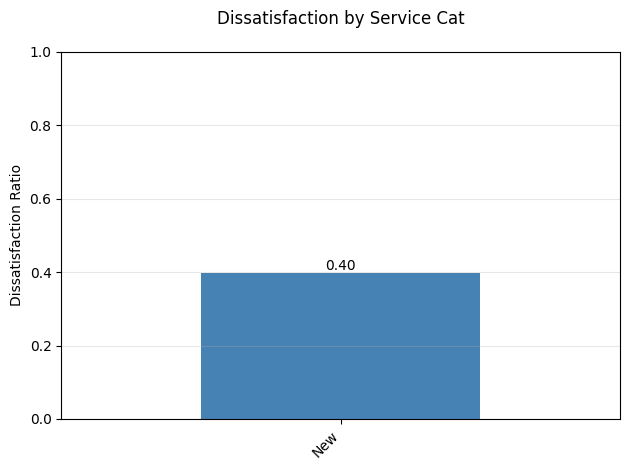


Generating plot for age_cat...


<Figure size 1000x600 with 0 Axes>

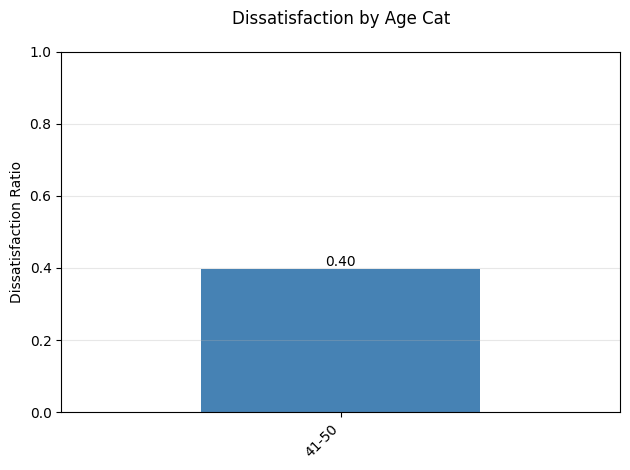


Generating plot for gender...


<Figure size 1000x600 with 0 Axes>

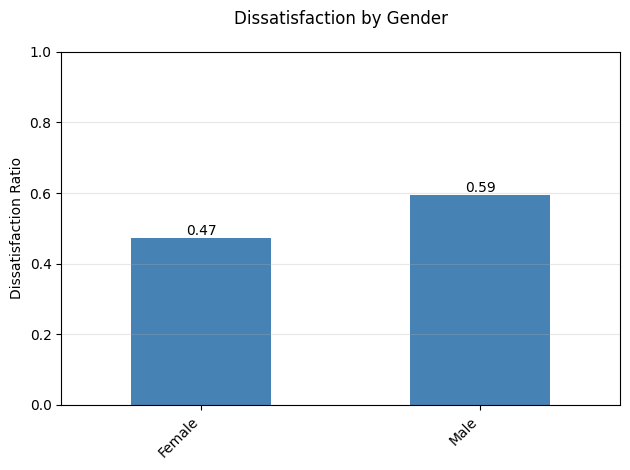


Generating plot for institute...


<Figure size 1000x600 with 0 Axes>

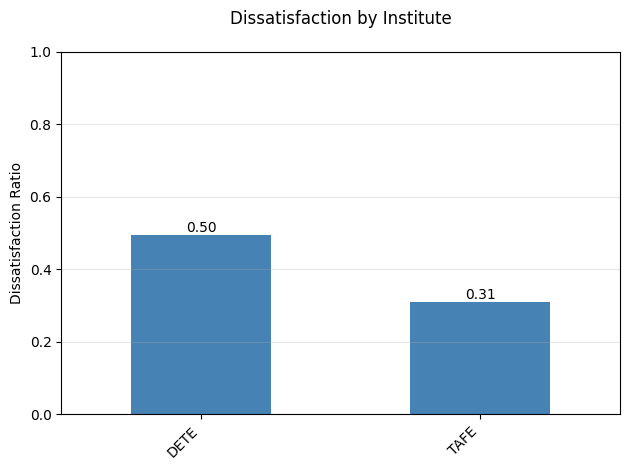


Generating plot for position_cat...


<Figure size 1000x600 with 0 Axes>

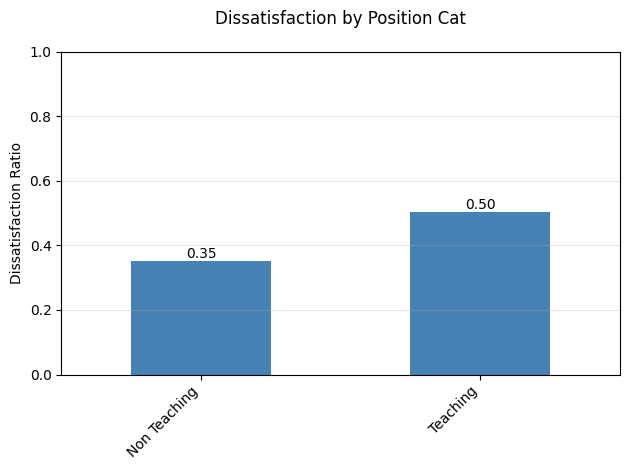


Generating plot for cleaned_employment_status...


<Figure size 1000x600 with 0 Axes>

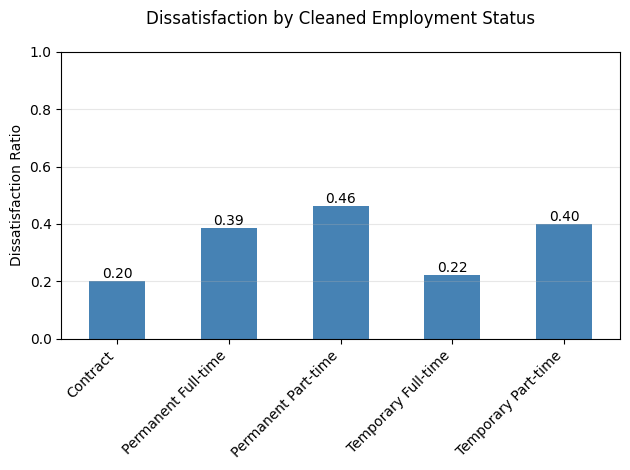


Plot generation complete!


In [12]:
import matplotlib.pyplot as plt

def make_plot(index_col, title, filename):
    """Create and save a bar plot of dissatisfaction ratios by category."""
    try:
        # Check if required columns exist
        if index_col not in combined.columns:
            print(f"Warning: Column '{index_col}' not found. Skipping this plot.")
            print(f"Available columns: {combined.columns.tolist()}")
            return None

        if 'dissatisfied' not in combined.columns:
            print("Error: 'dissatisfied' column not found. Cannot create plots.")
            return None

        # Create pivot table
        pivot = combined.pivot_table(index=index_col, values='dissatisfied', aggfunc='mean')

        # Create plot
        plt.figure(figsize=(10, 6))
        ax = pivot.plot(kind='bar', legend=False, color='steelblue')

        # Customize plot
        plt.title(title, pad=20)
        plt.xlabel('')
        plt.ylabel('Dissatisfaction Ratio')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)

        # Add value labels
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.2f}",
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 5),
                       textcoords='offset points')

        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()

        return pivot

    except Exception as e:
        print(f"Error creating plot for {index_col}: {str(e)}")
        return None

# First verify which columns we have
print("Available columns in DataFrame:", combined.columns.tolist())

# List of plots we want to generate (only including columns that exist)
plots_to_generate = []
possible_columns = ['service_cat', 'age_cat', 'gender', 'institute', 'position_cat', 'cleaned_employment_status']

for col in possible_columns:
    if col in combined.columns:
        title = f"Dissatisfaction by {col.replace('_', ' ').title()}"
        filename = f"{col}.png"
        plots_to_generate.append((col, title, filename))

# Generate plots only for existing columns
for col, title, fname in plots_to_generate:
    print(f"\nGenerating plot for {col}...")
    make_plot(col, title, fname)

print("\nPlot generation complete!")

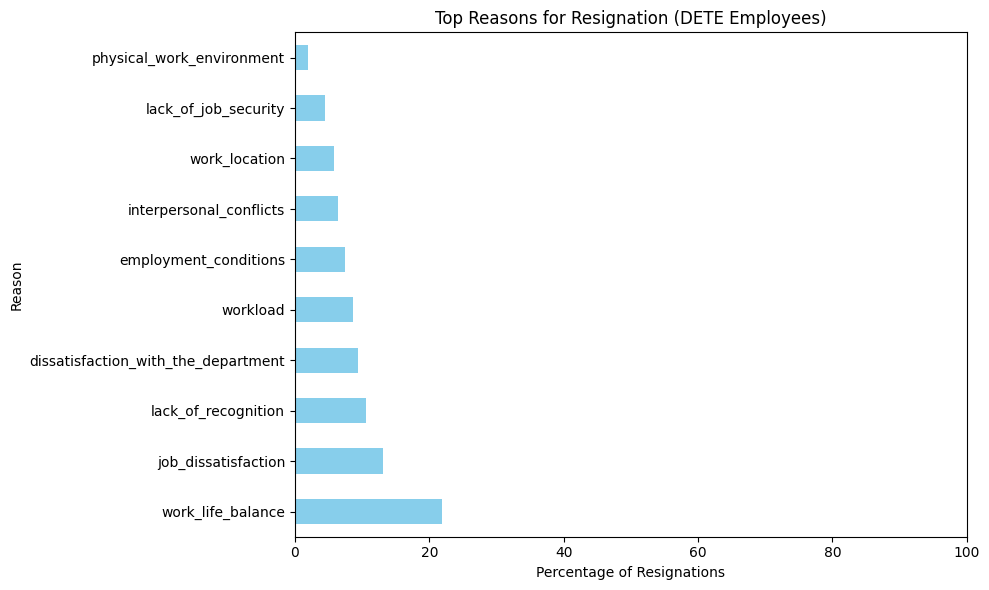

In [13]:
# Select resignation reason columns from DETE
dete_reason_cols = [
    'job_dissatisfaction',
    'dissatisfaction_with_the_department',
    'physical_work_environment',
    'lack_of_recognition',
    'lack_of_job_security',
    'work_location',
    'employment_conditions',
    'work_life_balance',
    'workload',
    'interpersonal_conflicts'
]

# Calculate the percentage of each reason
dete_reasons = dete_res[dete_reason_cols].mean().sort_values(ascending=False) * 100

# Plot resignation reasons (DETE)
plt.figure(figsize=(10, 6))
dete_reasons.plot(kind='barh', color='skyblue')
plt.title('Top Reasons for Resignation (DETE Employees)')
plt.xlabel('Percentage of Resignations')
plt.ylabel('Reason')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

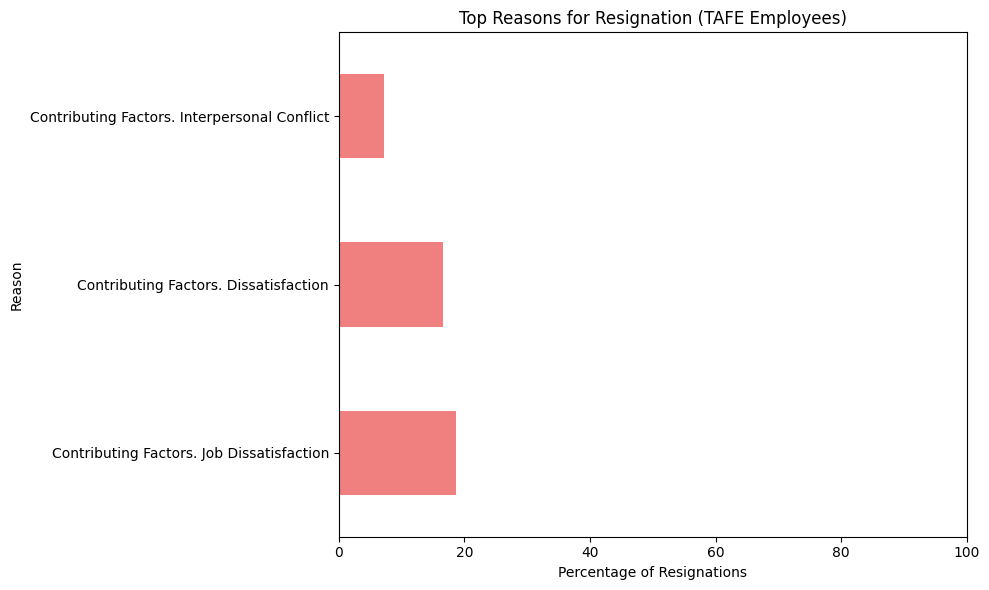

In [14]:
# Select resignation reason columns from TAFE
tafe_reason_cols = [
    'Contributing Factors. Dissatisfaction',
    'Contributing Factors. Job Dissatisfaction',
    'Contributing Factors. Interpersonal Conflict'
]

# Calculate the percentage of each reason
tafe_reasons = tafe_res[tafe_reason_cols].mean().sort_values(ascending=False) * 100

# Plot resignation reasons (TAFE)
plt.figure(figsize=(10, 6))
tafe_reasons.plot(kind='barh', color='lightcoral')
plt.title('Top Reasons for Resignation (TAFE Employees)')
plt.xlabel('Percentage of Resignations')
plt.ylabel('Reason')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()